In [19]:
!pip3 install -r ../requirements.txt 


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [20]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "src").is_dir() and (path / "data").is_dir():
            return path

    raise FileNotFoundError("프로젝트 루트 폴더를 찾을 수 없습니다.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/yundong-ug/dev/boot_camp/kaggle-titanic-ml


In [21]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import plotly as pl
import matplotlib as mat
import sklearn as sk
import seaborn as sns

import src.visualization as viz

print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'plotly: {pl.__version__}')
print(f'matplotlib: {mat.__version__}')
print(f'sklearn: {sk.__version__}')
print(f'seaborn: {sns.__version__}')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
numpy: 2.5.2
pandas: 3.0.5
plotly: 6.9.0
matplotlib: 3.11.1
sklearn: 1.9.0
seaborn: 0.13.2


In [22]:
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("설정 완료")

설정 완료


In [23]:
# 그래프 제목에 한글을 쓰면, 폰트가 없을 때 네모(□□□)로 깨집니다.
# 운영체제마다 한글 폰트 이름이 다르기 때문에, 있는 것을 자동으로 찾아 씁니다.
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action="ignore")

# 후보 폰트: 맥 / 윈도우 / 리눅스(Colab) 순서
candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "NanumBarunGothic"]

# 현재 컴퓨터에 설치된 폰트 이름을 모두 모읍니다.
installed = {f.name for f in fm.fontManager.ttflist}

# 후보 중 실제로 설치된 첫 번째 폰트를 선택합니다.
chosen = next((c for c in candidates if c in installed), None)

if chosen:
    plt.rcParams["font.family"] = chosen
    print(f"한글 폰트 설정 완료: {chosen}")
else:
    # 하나도 없으면 한글이 깨집니다. Colab이라면 아래 주석을 풀고 설치하세요.
    # !apt-get install -y fonts-nanum > /dev/null && fc-cache -fv
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 한글 폰트를 쓰면 축의 마이너스 기호가 깨지는 문제가 있어 함께 꺼 줍니다.
plt.rcParams["axes.unicode_minus"] = False

한글 폰트 설정 완료: AppleGothic


In [24]:
train_df, test_df= (pd.read_csv('../data/raw/train.csv'), pd.read_csv('../data/raw/test.csv'))

print(f'train_df.shape: {train_df.shape}, test_df.shape: {test_df.shape}')

train_df.shape: (891, 12), test_df.shape: (418, 11)


In [25]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [26]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [28]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [30]:
print(len(train_df.columns), train_df.columns)

12 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [31]:
print(len(test_df.columns), test_df.columns)

11 Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


In [32]:
experiment_log = []

def run_experiment(name, pipline, X_tr, y_tr, X_va, y_va, cv=5):
    """모델을 학습시키고, 성능과 하이퍼파라미터를 experiment_log에 자동으로 기록합니다.
    
    반환값은 지금까지의 전체 실험 기록을 검증 정확도 순으로 정렬한 DataFrame입니다.
    """
    pipline.fit(X_tr, y_tr)

    cv_scores = cross_val_score(pipline, X_tr, y_tr, cv=cv, scoring='accuracy')
    row = {
        'test_name': name,
        'train_acc': pipline.score(X_tr, y_tr),
        'valid_acc': pipline.score(X_va, y_va),
        'CV_avg': cv_scores.mean(),
        'CV_std': cv_scores.std(),
    }

    row.update(pipline.named_steps['model'].get_params())
    experiment_log.append(row)

    log_df = pd.DataFrame(experiment_log)
    return log_df.sort_values('valid_acc', ascending=False).reset_index(drop=True)

def show_log(columns=None):
    """실험 기록을 보여줍니다. columns를 지정하면 그 컬럼들만 골라서 봅니다.
    
    예: show_log(["실험명", "검증 정확도", "n_estimators", "max_depth"])
    """
    log_df = pd.DataFrame(experiment_log).sort_values('valid_acc', ascending=False).reset_index(drop=True)
    return log_df[columns] if columns else log_df

In [33]:
eda_df = train_df.copy()

print(eda_df.isnull().sum())
print()
print('Overall survival:', eda_df['Survived'].mean().round(3))

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Overall survival: 0.384


| 컬럼명 | 데이터 타입 | 설명 |
|---|---|---|
| `PassengerId` | int | 승객 고유 번호. 제출 파일의 키로 사용됩니다. |
| `Survived` | int | 타깃 변수. 생존 여부(0: 사망, 1: 생존). `train` 데이터에만 존재하며 예측 대상입니다. |
| `Pclass` | int | 티켓 등급(1: 1등석, 2: 2등석, 3: 3등석). 사회경제적 지위를 대신 보여주는 변수입니다. |
| `Name` | object | 승객 이름. `Mr`, `Mrs`, `Miss`, `Master` 같은 호칭이 포함되어 있습니다. |
| `Sex` | object | 성별. |
| `Age` | float | 나이. 1살 미만은 소수점으로 표기됩니다. |
| `SibSp` | int | 함께 탑승한 형제자매와 배우자 수. |
| `Parch` | int | 함께 탑승한 부모와 자녀 수. |
| `Ticket` | object | 티켓 번호. |
| `Fare` | float | 운임. |
| `Cabin` | object | 객실 번호. |
| `Embarked` | object | 탑승 항구 (`C`: Cherbourg, `Q`: Queenstown, `S`: Southampton). |

# EDA

In [34]:
# 나이 결측치 처리를 위해 각 변수별 탐색
# 나이대별로 성별이 어떻게 분포되어 있는가 -> 히스토그램
# 성별별 생존율 -> bar
# 나이대와 성별과의 생존율 상관관계 -> bar
# pclass(int -> 범주)와 성별(object -> 범주)생존율 상관관계


AGE_BINS = [0, 10, 20, 30, 40, 50, 60, 80]
AGE_LABELS = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-80",
]

TITLE_ORDER = ["Mr", "Mrs", "Miss", "Master", "Other"]
MERGED_TITLE_ORDER = ["Mr", "Mrs", "Miss", "Master"]
SEX_ORDER = ["male", "female"]

# 나이 분포 × 성별
viz.plot_histogram(
    eda_df,
    x="Age",
    color="Sex",
    title="Age Distribution by Sex",
    category_orders={"Sex": SEX_ORDER},
).show()

# 성별 생존율
viz.plot_survival_rate(
    eda_df,
    x="Sex",
    title="Survival Rate by Sex",
    category_orders={"Sex": SEX_ORDER},
).show()


age_bins = [0, 10, 20, 30, 40, 50, 60, 80]
age_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-80']

eda_df['AgeGroup'] = pd.cut(
    eda_df['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)


# 나이대 × 성별 생존율
viz.plot_survival_rate(
    eda_df,
    x="AgeGroup",
    color="Sex",
    title="Survival Rate by Age Group and Sex",
    category_orders={
        "AgeGroup": AGE_LABELS,
        "Sex": SEX_ORDER,
    },
    show_count=True,
).show()

In [35]:
# Pclass 별 전체 명수 -> bar plot
# Pclass 성별별 생존율 -> bar plot
# Pclass 별 나이대 분포 -> hist plot


# 1. Pclass 별 전체 명수 -> bar plot

viz.plot_count_bar(
    eda_df,
    x="Pclass",
    title="Passenger Count by Pclass",
).show()


# 2. Pclass 성별별 생존율 -> bar plot

viz.plot_survival_rate(
    eda_df,
    x="Pclass",
    color="Sex",
    title="Survival Rate by Pclass and Sex",
    category_orders={"Sex": SEX_ORDER},
).show()

# 3. Pclass 별 나이대 분포 -> histogram

viz.plot_histogram(
    eda_df.assign(Pclass=eda_df["Pclass"].astype(str)),
    x="Age",
    color="Pclass",
    title="Age Distribution by Pclass",
    category_orders={"Pclass": ["1", "2", "3"]},
).show()


In [36]:
# 승객 이름에 `Mr`, `Mrs`, `Miss`, `Master`가 포함되지 않는 명수 확인

mask = ~eda_df['Name'].str.contains(
    r'\b(Mr|Mrs|Miss|Master)\b',
    regex=True,
    na=False
)

count = mask.sum()

print(count)

eda_df.loc[mask, 'Name']

# title 별 인원수가 어떻게 되는가 확인 -> bar plot

# 이름에서 호칭 추출
eda_df['Title'] = eda_df['Name'].str.extract(
    r',\s*([^.]*)\.'
)[0]

# Mr, Mrs, Miss, Master 외에는 Other로 묶기
eda_df['Title'] = eda_df['Title'].where(
    eda_df['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master']),
    'Other'
)

# 호칭별 인원 수
title_count = (
    eda_df['Title']
    .value_counts()
    .reset_index()
)

title_count.columns = ['Title', 'Count']

viz.plot_count_bar(
    eda_df,
    x="Title",
    title="Passenger Count by Title",
    category_orders={"Title": TITLE_ORDER},
).show()


#title의 other의 분포가 적어서 다른 title과 합쳐도 좋지 않을까 싶어 성별 확인해보니 남성과 여성이 other에 섞여 있어서 남성은 mr로 여성은 mrs로
viz.plot_count_bar(
    eda_df,
    x="Title",
    color="Sex",
    title="Sex Distribution by Title",
    category_orders={
        "Title": TITLE_ORDER,
        "Sex": SEX_ORDER,
    },
).show()

# title 별 나이 분포 어떻게 되는가 확인 -> bar plot
viz.plot_box_distribution(
    eda_df,
    x="Title",
    y="Age",
    color="Title",
    title="Age Distribution by Title",
    category_orders={"Title": TITLE_ORDER},
).show()


eda_df['TitleMerged'] = eda_df['Title']

eda_df.loc[
    (eda_df['Title'] == 'Other') &
    (eda_df['Sex'] == 'male'),
    'TitleMerged'
] = 'Mr'

eda_df.loc[
    (eda_df['Title'] == 'Other') &
    (eda_df['Sex'] == 'female'),
    'TitleMerged'
] = 'Mrs'


viz.plot_box_distribution(
    eda_df,
    x="TitleMerged",
    y="Age",
    color="TitleMerged",
    title="Age Distribution by Merged Title",
    category_orders={
        "TitleMerged": MERGED_TITLE_ORDER,
    },
).show()

# box plot을 보고 합쳐도 된다고 생각했으나. 나이대를 나누어 타이틀별로 히트맵을 찍어보니 other로 나눌 때와 나누지 않을 때의 평균이 흔들리는 것을 확인하여 other로 분리하기로 함.

# 4. Other를 유지했을 때 Title × AgeGroup 생존율

viz.plot_survival_heatmap(
    eda_df,
    row="Title",
    column="AgeGroup",
    title="Survival Rate by Title and Age Group",
    row_order=TITLE_ORDER,
    column_order=AGE_LABELS,
).show()

eda_df['AgeGroup'] = pd.cut(
    eda_df['Age'],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# 5. Other를 합쳤을 때 TitleMerged × AgeGroup 생존율

viz.plot_survival_heatmap(
    eda_df,
    row="TitleMerged",
    column="AgeGroup",
    title="Survival Rate by Merged Title and Age Group",
    row_order=MERGED_TITLE_ORDER,
    column_order=AGE_LABELS,
).show()


24


In [41]:
# 1. SibSp에 따른 생존율

viz.plot_survival_rate(
    eda_df,
    x="SibSp",
    title="Survival Rate by SibSp",
    show_count=True,
).show()

# 2. Parch에 따른 생존율

viz.plot_survival_rate(
    eda_df,
    x="Parch",
    title="Survival Rate by Parch",
    show_count=True,
).show()

alone_count = (
    (eda_df["SibSp"] == 0)
    & (eda_df["Parch"] == 0)
).sum()

alone_ratio = alone_count / len(eda_df)

print(f"가족 없이 탑승한 승객: {alone_count}명 ({alone_ratio:.1%})")

eda_df["FamilySize"] = (
    eda_df["SibSp"]
    + eda_df["Parch"]
    + 1
)

viz.plot_survival_rate(
    eda_df,
    x="FamilySize",
    title="Survival Rate by Family Size",
    show_count=True,
).show()



가족 없이 탑승한 승객: 537명 (60.3%)


# EDA 결론
---
## 핵심 feature
`Age`, `Sex`, `Name`, `SlibSP`, `Parch`

### 근거
```python
# 이름에서 호칭 추출
eda_df['Title'] = eda_df['Name'].str.extract(
    r',\s*([^.]*)\.'
)[0]

# Mr, Mrs, Miss, Master 외에는 Other로 묶기
eda_df['Title'] = eda_df['Title'].where(
    eda_df['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master']),
    'Other'
)

```

`Name`에서 Mr, Mrs, Miss, Master를 추출하였고, 그 외에 이름은 Other로 취급하였을 때 Mr가 그룹이 생존율이 특별히 낮은 것을 확인하였고, 그외에 그룹들도 생존율이 고루 퍼져 있어 **핵심 Feature**로 유의미하다고 판단
<br>
<br>
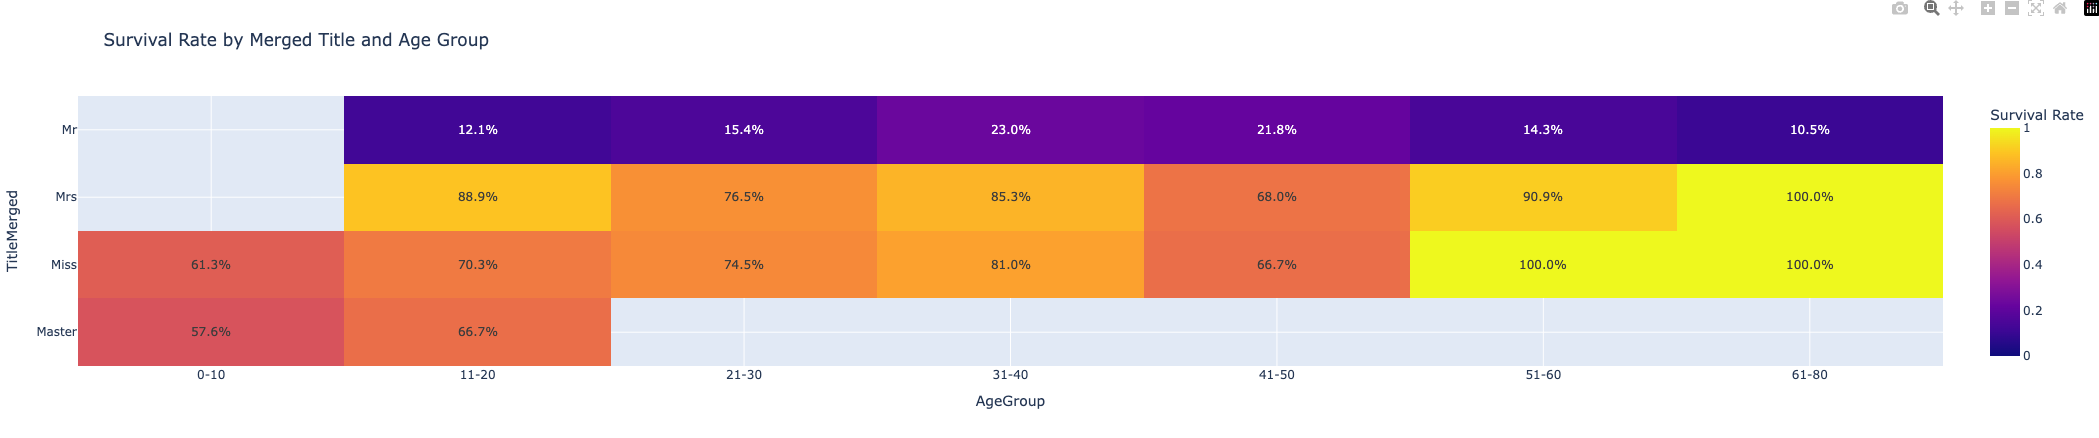